Top 10 palabras más frecuentes:
[('al', 51), ('peso', 37), ('dólar', 35), ('frente', 35), ('de', 28), ('el', 22), ('impulsa', 21), ('colombiano', 21), ('en', 18), ('fortalece', 15)]


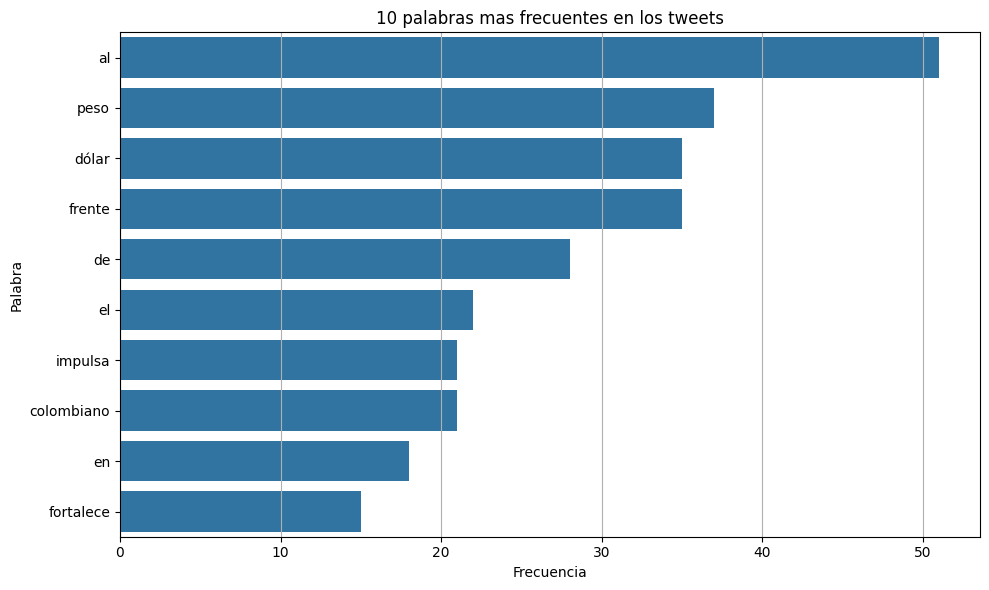

               id    label  is_train
id        1.00000 -0.05145       NaN
label    -0.05145  1.00000       NaN
is_train      NaN      NaN       NaN


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import seaborn as sns
import math

df = pd.read_csv('trainTw.csv') 
df = df[df['is_train'] == True]

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  
    return text.split()

all_words = []
df['texto'].apply(lambda x: all_words.extend(preprocess_text(x)))
word_freq = Counter(all_words)
common_words = word_freq.most_common(10)
print("Top 10 palabras más frecuentes:")
print(common_words)


words, counts = zip(*common_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title("10 palabras mas frecuentes en los tweets")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)
label_correlation = correlation_matrix["label"].drop("label")



In [59]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression_manual(X, y, learning_rate=0.05, batch_size=5, max_iterations=1000, track_iterations=[1, 100, 500, 1000]):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    m, n = X.shape
    weights = np.zeros(n)
    results = {}
    
    for iteration in range(1, max_iterations+1):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            batch_m = X_batch.shape[0]
            
            z = np.dot(X_batch, weights)
            predictions = sigmoid(z)
        
            error = predictions - y_batch
            gradient = np.dot(X_batch.T, error) / batch_m
            
            weights -= learning_rate * gradient
        
        if iteration in track_iterations:
            results[iteration] = weights.copy()
        
    
    return results

data = pd.read_csv('trainTw.csv')
train_data = data[data['is_train'] == True]

keywords = ['aumento', 'inestabilidad']
X = []
for text in train_data['texto']:
    features = [
        1 if 'aumento' in text.lower() else 0,
        1 if 'inestabilidad' in text.lower() else 0
    ]
    X.append(features)
X = np.array(X)
y = train_data['label'].values

track_iterations = [1, 100, 500, 1000]

X_m1 = X[:, 0].reshape(-1, 1)
results_m1 = logistic_regression_manual(X_m1, y, track_iterations=track_iterations)

X_m2 = X[:, 1].reshape(-1, 1)
results_m2 = logistic_regression_manual(X_m2, y, track_iterations=track_iterations)

# Crear tabla de resultados
table_data = []
for it in track_iterations:
    row = {
        'iteracion': it,
        'aumento M2': 0.0, 
        'aumento M1': results_m1[it][1],  
        'inestabilidad M1': 0.0, 
        'inestabilidad M2': results_m2[it][1] 
    }
    table_data.append(row)

result_df = pd.DataFrame(table_data)
print("\nTabla de coeficientes por iteración:")
print(result_df.to_string(index=False))

print("\nCoeficientes finales M1:")
print(f"Intercepto (bias): {results_m1[1000][0]:.6f}")
print(f"'aumento': {results_m1[1000][1]:.6f}")

print("\nCoeficientes finales M2:")
print(f"Intercepto (bias): {results_m2[1000][0]:.6f}")
print(f"'inestabilidad': {results_m2[1000][1]:.6f}")


Tabla de coeficientes por iteración:
 iteracion  aumento M2  aumento M1  inestabilidad M1  inestabilidad M2
         1         0.0   -0.000062               0.0               0.0
       100         0.0   -0.104627               0.0               0.0
       500         0.0   -0.277882               0.0               0.0
      1000         0.0   -0.306137               0.0               0.0

Coeficientes finales M1:
Intercepto (bias): 0.303639
'aumento': -0.306137

Coeficientes finales M2:
Intercepto (bias): 0.286272
'inestabilidad': 0.000000


In [60]:
#Solo verificasion!!!!!
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

data = pd.read_csv('trainTw.csv')
train_data = data[data['is_train'] == True]
keywords = ['aumento', 'inestabilidad']
def extract_features(text, keywords):
    features = {}
    text_lower = text.lower()
    for word in keywords:
        features[f'has_{word}'] = 1 if word in text_lower else 0
    return features
X = []
y = []

for _, row in train_data.iterrows():
    features = extract_features(row['texto'], keywords)
    X.append([features['has_aumento'], features['has_inestabilidad']])
    y.append(row['label'])

X = np.array(X)
y = np.array(y)


model_m1 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
model_m1.fit(X[:, 0].reshape(-1, 1), y)  # Solo primera característica

model_m2 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
model_m2.fit(X[:, 1].reshape(-1, 1), y)  # Solo segunda característica

print("Resultados con scikit-learn:")
print("\nModelo M1 (solo 'aumento'):")
print(f"Coeficiente para 'aumento': {model_m1.coef_[0][0]:.4f}")
print(f"Intercepto: {model_m1.intercept_[0]:.4f}")

print("\nModelo M2 (solo 'inestabilidad'):")
print(f"Coeficiente para 'inestabilidad': {model_m2.coef_[0][0]:.4f}")
print(f"Intercepto: {model_m2.intercept_[0]:.4f}")


from sklearn.metrics import accuracy_score

y_pred_m1 = model_m1.predict(X[:, 0].reshape(-1, 1))
y_pred_m2 = model_m2.predict(X[:, 1].reshape(-1, 1))
y_pred_full = model_full.predict(X)

Resultados con scikit-learn:

Modelo M1 (solo 'aumento'):
Coeficiente para 'aumento': -0.3056
Intercepto: 0.3055

Modelo M2 (solo 'inestabilidad'):
Coeficiente para 'inestabilidad': 0.0000
Intercepto: 0.2876


In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('wordnet')

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression_manual(X, y, learning_rate=0.05, batch_size=5, max_iterations=1000, track_iterations=[1, 100, 500, 1000]):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    m, n = X.shape
    weights = np.zeros(n) 
    results = {}
    
    for iteration in range(1, max_iterations+1):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            batch_m = X_batch.shape[0]
            
            z = np.dot(X_batch, weights)
            predictions = sigmoid(z)
        
            error = predictions - y_batch
            gradient = np.dot(X_batch.T, error) / batch_m
            
            weights -= learning_rate * gradient
        
        if iteration in track_iterations:
            results[iteration] = weights.copy()
    
    return weights 

def predict(X, weights):
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    z = np.dot(X_with_bias, weights)
    predictions = sigmoid(z)
    return (predictions >= 0.5).astype(int)

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    tokens = word_tokenize(text)
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmas)

data = pd.read_csv('trainTw.csv')
train_data = data[data['is_train'] == True]
test_data = data[data['is_train'] == False]

train_data['processed_text'] = train_data['texto'].apply(preprocess_text)
test_data['processed_text'] = test_data['texto'].apply(preprocess_text)

vectorizer = TfidfVectorizer(max_features=1000, stop_words=['el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas', 'al', 'del'])
X_train_tfidf = vectorizer.fit_transform(train_data['processed_text']).toarray()
X_test_tfidf = vectorizer.transform(test_data['processed_text']).toarray() 

y_train = train_data['label'].values
y_test = test_data['label'].values

weights = logistic_regression_manual(X_train_tfidf, y_train, learning_rate=0.05, max_iterations=1000)

def evaluate_model(X, y, weights, data_type='Train'):
    y_pred = predict(X, weights)
    f1 = f1_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    
    print(f"\nMétricas para {data_type}:")
    print(f"F1-Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    
    return f1, precision, recall


train_metrics = evaluate_model(X_train_tfidf, y_train, weights, 'Train')
test_metrics = evaluate_model(X_test_tfidf, y_test, weights, 'Test')

feature_names = vectorizer.get_feature_names_out()
coefficients = weights[1:]  

word_importance = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients
})


word_importance = word_importance.sort_values('coefficient', ascending=False)

top_5_increase = word_importance.head(5)
print("\nTop 5 palabras relacionadas con aumento del dolar:")
print(top_5_increase[['word', 'coefficient']].to_string(index=False))

top_5_decrease = word_importance.tail(5).iloc[::-1]
print("\nTop 5 palabras relacionadas con detrimento del dolar:")
print(top_5_decrease[['word', 'coefficient']].to_string(index=False))


Métricas para Train:
F1-Score: 1.0000
Precision: 1.0000
Recall: 1.0000

Métricas para Test:
F1-Score: 1.0000
Precision: 1.0000
Recall: 1.0000

Top 5 palabras relacionadas con aumento del dolar:
      word  coefficient
   impulsa     4.897262
colombiano     4.894430
     caída     1.827541
      país     1.327099
     sobre     1.103656

Top 5 palabras relacionadas con detrimento del dolar:
       word  coefficient
  fortalece    -6.519289
estabilidad    -1.700040
  república    -1.264854
      banco    -1.264854
   gobierno    -1.115413


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brahiansanabria/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brahiansanabria/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_5465/3389489664.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['processed_text'] = train_data['texto'].apply(preprocess_text)
/var/folders/l_/q54w5zm5149dxh0wmf6hgmch0000gn/T/ipykernel_5465/3389489664.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the document

In [66]:
from nltk.tokenize import word_tokenize
from sklearn.metrics import f1_score, precision_score, recall_score

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_regression_manual(X, y, learning_rate=0.05, batch_size=5, max_iterations=1000, track_iterations=[1, 100, 500, 1000]):
    X = np.hstack([np.ones((X.shape[0], 1)), X])
    
    m, n = X.shape
    weights = np.zeros(n)  
    results = {}
    
    for iteration in range(1, max_iterations+1):
        for i in range(0, m, batch_size):
            # Obtener batch actual
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]
            batch_m = X_batch.shape[0]
            z = np.dot(X_batch, weights)
            predictions = sigmoid(z)
            error = predictions - y_batch
            gradient = np.dot(X_batch.T, error) / batch_m
            
            weights -= learning_rate * gradient
        
        # Registrar resultados en iteraciones específicas
        if iteration in track_iterations:
            results[iteration] = weights.copy()
    
    return results

embeddings_df = pd.read_csv('embedding.csv')
embeddings = dict(zip(embeddings_df['word'], embeddings_df['embedding_1d']))

def text_to_embedding(text):
    tokens = word_tokenize(str(text).lower())
    word_embeddings = [embeddings.get(token, 0) for token in tokens]  
    return np.mean(word_embeddings) if word_embeddings else 0

data = pd.read_csv('trainTw.csv')
train_data = data[data['is_train'] == True]
test_data = data[data['is_train'] == False]

X_train = np.array([text_to_embedding(text) for text in train_data['texto']]).reshape(-1, 1)
X_test = np.array([text_to_embedding(text) for text in test_data['texto']]).reshape(-1, 1)

y_train = train_data['label'].values
y_test = test_data['label'].values

track_iterations = [1, 100, 500, 1000]
results = logistic_regression_manual(X_train, y_train, track_iterations=track_iterations)

# Obtener pesos finales
final_weights = results[1000]
bias = final_weights[0]
weight = final_weights[1]

print(f"\nCoeficientes finales:")
print(f"Bias (intercepto): {bias:.6f}")
print(f"Peso para embedding: {weight:.6f}")

def evaluate_manual_model(X, y, weights, data_type='Train'):
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    z = np.dot(X_with_bias, weights)
    predictions = (sigmoid(z) > 0.5).astype(int)
    
    f1 = f1_score(y, predictions)
    precision = precision_score(y, predictions)
    recall = recall_score(y, predictions)
    
    print(f"\nMétricas para {data_type}:")
    print(f"F1-Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    
    return f1, precision, recall

train_metrics = evaluate_manual_model(X_train, y_train, final_weights, 'Train')
test_metrics = evaluate_manual_model(X_test, y_test, final_weights, 'Test')

word_importance = embeddings_df.copy()
word_importance['impacto'] = word_importance['embedding_1d'] * weight
word_importance['abs_impacto'] = word_importance['impacto'].abs()
word_importance = word_importance.sort_values('abs_impacto', ascending=False)

top_5_increase = word_importance[word_importance['impacto'] > 0].head(5)
print("\nTop 5 palabras relacionadas con aumento del dólar:")
print(top_5_increase[['word', 'embedding_1d', 'impacto']].to_string(index=False))

top_5_decrease = word_importance[word_importance['impacto'] < 0].head(5)
print("\nTop 5 palabras relacionadas con detrimento del dólar:")
print(top_5_decrease[['word', 'embedding_1d', 'impacto']].to_string(index=False))


Coeficientes finales:
Bias (intercepto): 0.286576
Peso para embedding: 0.118140

Métricas para Train:
F1-Score: 0.7273
Precision: 0.5714
Recall: 1.0000

Métricas para Test:
F1-Score: 0.5000
Precision: 0.3333
Recall: 1.0000

Top 5 palabras relacionadas con aumento del dólar:
  word  embedding_1d  impacto
   los      0.047689 0.005634
genera      0.039722 0.004693
subida      0.038968 0.004604
 china      0.036891 0.004358
alerta      0.034075 0.004026

Top 5 palabras relacionadas con detrimento del dólar:
      word  embedding_1d   impacto
    carbón     -0.044779 -0.005290
proyección     -0.038458 -0.004543
     prima     -0.036343 -0.004294
     dólar     -0.033183 -0.003920
     éxito     -0.028801 -0.003403


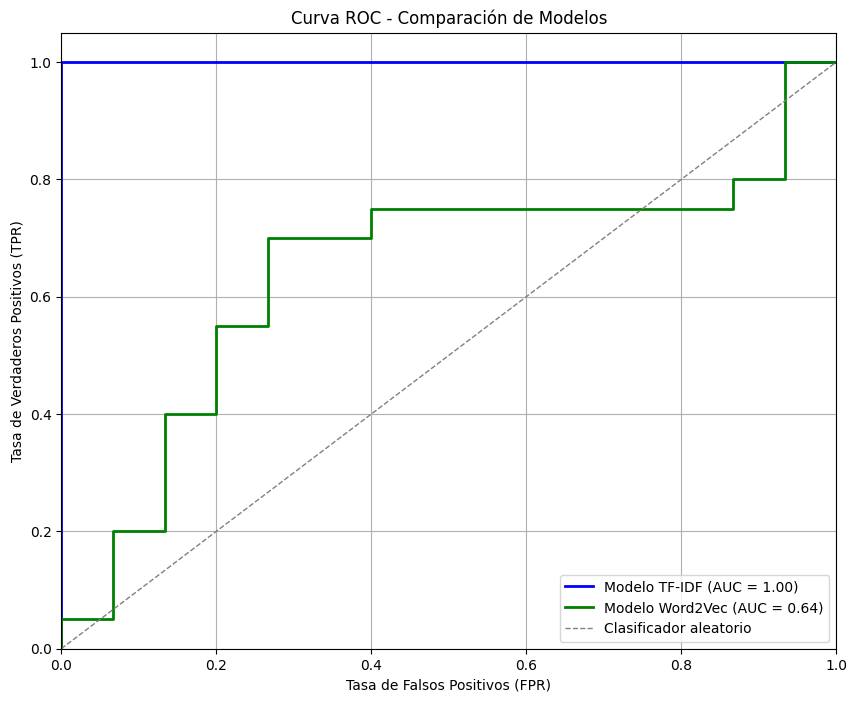

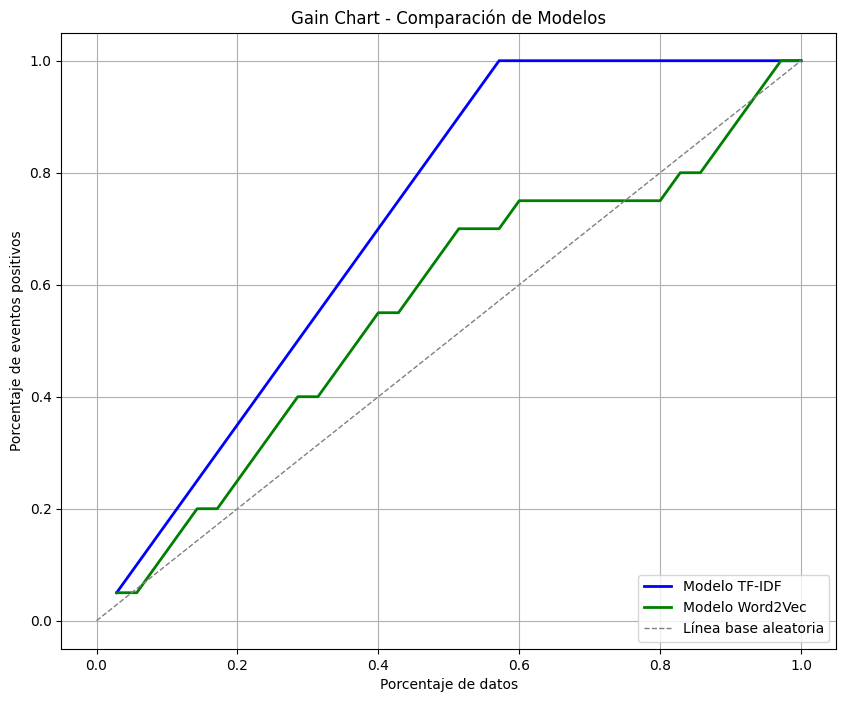

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def calculate_roc_metrics(X, y, weights):
    X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
    z = np.dot(X_with_bias, weights)
    probabilities = sigmoid(z)
    fpr, tpr, _ = roc_curve(y, probabilities)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# TF-IDF
fpr_tfidf, tpr_tfidf, auc_tfidf = calculate_roc_metrics(X_train_tfidf, y_train, weights)

# Embeddings
fpr_emb, tpr_emb, auc_emb = calculate_roc_metrics(X_train, y_train, final_weights)

plt.figure(figsize=(10, 8))
plt.plot(fpr_tfidf, tpr_tfidf, color='blue', lw=2, 
         label=f'Modelo TF-IDF (AUC = {auc_tfidf:.2f})')
plt.plot(fpr_emb, tpr_emb, color='green', lw=2, 
         label=f'Modelo Word2Vec (AUC = {auc_emb:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


def calculate_gain_data(y_true, y_prob):
    df = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df = df.sort_values('y_prob', ascending=False)
    df['cumulative_data'] = np.arange(1, len(df)+1) / len(df)
    df['cumulative_positive'] = df['y_true'].cumsum() / df['y_true'].sum()
    return df['cumulative_data'], df['cumulative_positive']

X_with_bias = np.hstack([np.ones((X_train_tfidf.shape[0], 1)), X_train_tfidf])
z = np.dot(X_with_bias, weights)
prob_tfidf = sigmoid(z)
x_tfidf, y_tfidf = calculate_gain_data(y_train, prob_tfidf)

X_with_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
z = np.dot(X_with_bias, final_weights)
prob_emb = sigmoid(z)
x_emb, y_emb = calculate_gain_data(y_train, prob_emb)

plt.figure(figsize=(10, 8))
plt.plot(x_tfidf, y_tfidf, color='blue', lw=2, label='Modelo TF-IDF')
plt.plot(x_emb, y_emb, color='green', lw=2, label='Modelo Word2Vec')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Línea base aleatoria')

plt.xlabel('Porcentaje de datos')
plt.ylabel('Porcentaje de eventos positivos')
plt.title('Gain Chart - Comparación de Modelos')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()